In [66]:
from defense_utils import flatten_lora_params, compute_wa_distances, extract_lora_qs, extract_lora_vals
from defense import krum, multi_krum, detect_anomalies_by_distance, bulyan, detect_outliers_from_weights, trimmed_mean
from transformers import (
    DistilBertForSequenceClassification, 
    DistilBertTokenizer, 
    RobertaForSequenceClassification, 
    RobertaTokenizer,
    BertForSequenceClassification,
    BertTokenizer)
from peft import get_peft_model, LoraConfig, PeftModel
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import pickle
import torch 

bert_lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.01,
            task_type="SEQ_CLS",
        )

distilbert_lora_config = LoraConfig(
    r=12,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)
    
roberta_lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "key", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

def load_client_weights(file_path):
    """
    Load client weights from pickle file for all epochs.
    
    Args:
        file_path: Path to the pickle file
        
    Returns:
        dict: Dictionary with epochs as keys, each containing:
             - 'loss': List of loss values for each client
             - 'weights': List of weight arrays for each client
             - 'is_poisoned': List of indices of poisoned clients
    """
    # Load the pickle file
    with open(file_path, 'rb') as f:
        record = pickle.load(f)
    
    # Initialize output dictionary
    result = {}
    
    # Process each epoch
    for epoch_key in sorted(record.keys(), key=lambda x: int(x.split()[1])):
        epoch_data = record[epoch_key]
        
        # Initialize data structure for this epoch
        result[epoch_key] = {
            'loss': [],
            'weights': [],
            'is_poisoned': []
        }
        
        # Extract client data for this epoch
        client_keys = sorted(epoch_data.keys(), key=lambda x: int(x.split()[1]))
        
        for client_key in client_keys:
            client_data = epoch_data[client_key]
            result[epoch_key]['loss'].append(client_data['loss'])
            result[epoch_key]['weights'].append(client_data['weights'])
            if client_data['is_poisoned']:
                result[epoch_key]['is_poisoned'].append(int(client_key.split()[1]))
    
    return result

# Usage example
def load_epoch_data(epoch_num):
    """Load data for a specific epoch"""
    file_path = f"save_path/client_weights_epoch{epoch_num}.pkl"
    return load_client_weights(file_path)

# To load multiple epochs
def load_multiple_epochs(num_epochs):
    """Load data for multiple epochs"""
    all_epochs = []
    for epoch in range(num_epochs):
        epoch_data = load_epoch_data(epoch)
        all_epochs.append(epoch_data)
    return all_epochs

In [73]:
def plot_distances(model_name, clean_weights, client_weights, BD_users):
    if model_name == 'bert' or model_name == 'roberta':
        num_layers = 12
    elif model_name == 'distilbert':
        num_layers = 6
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    
    client_A_mat, client_B_mat = extract_lora_qs(model_name=model_name, 
                                                           clients_state_dicts=client_weights, 
                                                           num_layers=num_layers)
    clean_A_mat, clean_B_mat = extract_lora_qs(model_name=model_name, 
                                               clients_state_dicts=[clean_weights], 
                                               num_layers=num_layers)
    
    A_distances = compute_wa_distances(clean_A_mat, client_A_mat)
    B_distances = compute_wa_distances(clean_B_mat, client_B_mat)
    
    color_map = {
    'malicious': 'red',
    'benign': 'blue'
    }
    
    layers = np.arange(1, num_layers + 1)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

    # Plot A matrices distances on the top subplot
    for i in range(len(A_distances['Layer_1'])):
        if i in BD_users:
            ax1.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['malicious'], alpha=0.7, label='Malicious' if i == BD_users[0] else "")
        else:
            ax1.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['benign'], alpha=0.7, label='Benign' if i == 0 else "")

    ax1.set_title('Distance of A matrices from clean model')
    ax1.set_ylabel('Wasserstein Distance')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot B matrices distances on the bottom subplot
    for i in range(len(B_distances['Layer_1'])):
        if i in BD_users:
            ax2.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['malicious'], alpha=0.7, label='Malicious' if i == BD_users[0] else "")
        else:
            ax2.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['benign'], alpha=0.7, label='Benign' if i == 0 else "")

    ax2.set_title('Distance of B matrices from clean model')
    ax2.set_xlabel('Layer')
    ax2.set_ylabel('Wasserstein Distance')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_distances_across_epochs(model_name, clean_weights, epoch_data, num_epochs=None):
    """
    Plot distances between client weights and clean weights across all epochs.
    
    Args:
        model_name: Name of the model ('bert', 'roberta', or 'distilbert')
        clean_weights: The weights of the clean model
        epoch_data: Dictionary with epochs as keys from load_client_weights function
        num_epochs: Optional limit on number of epochs to plot (plots all if None)
    """
    if model_name == 'bert' or model_name == 'roberta':
        num_layers = 12
    elif model_name == 'distilbert':
        num_layers = 6
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    
    # Extract clean matrices
    clean_A_mat, clean_B_mat = extract_lora_qs(model_name=model_name, 
                                              clients_state_dicts=[clean_weights], 
                                              num_layers=num_layers)
    
    # Define colors
    color_map = {
        'malicious': 'red',
        'benign': 'blue'
    }
    
    # Sort epochs and limit if specified
    sorted_epochs = sorted(epoch_data.keys(), key=lambda x: int(x.split()[1]))
    if num_epochs is not None:
        sorted_epochs = sorted_epochs[:num_epochs]
    
    # Number of epochs to plot
    n_epochs = len(sorted_epochs)
    
    # Create a 2×n_epochs grid of subplots
    fig, axs = plt.subplots(2, n_epochs, figsize=(n_epochs*5, 10), sharex=True, sharey='row')
    
    # Create axis labels for all layers
    layers = np.arange(1, num_layers + 1)
    
    A_dis = []
    B_dis = []
    
    # Process each epoch
    for epoch_idx, epoch_key in enumerate(sorted_epochs):
        epoch_info = epoch_data[epoch_key]
        client_weights = epoch_info['weights']
        BD_users = epoch_info['is_poisoned']
        
        # Extract client matrices for this epoch
        client_A_mat, client_B_mat = extract_lora_qs(model_name=model_name, 
                                                   clients_state_dicts=client_weights, 
                                                   num_layers=num_layers)
        
        # Calculate distances
        A_distances = compute_wa_distances(clean_A_mat, client_A_mat)
        B_distances = compute_wa_distances(clean_B_mat, client_B_mat)
        
        A_dis.append(A_distances)
        B_dis.append(B_distances)
        
        # Get subplot for A distances (top row)
        ax_a = axs[0, epoch_idx]
        
        # Plot A matrices distances
        has_malicious_legend = False
        has_benign_legend = False
        
        for i in range(len(A_distances['Layer_1'])):
            if i in BD_users:
                label = 'Malicious' if not has_malicious_legend else ""
                has_malicious_legend = True if label else has_malicious_legend
                
                ax_a.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', 
                         color=color_map['malicious'], alpha=0.7, label=label)
            else:
                label = 'Benign' if not has_benign_legend else ""
                has_benign_legend = True if label else has_benign_legend
                
                ax_a.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', 
                         color=color_map['benign'], alpha=0.7, label=label)
        
        # Set title and labels for A subplot
        ax_a.set_title(f'A matrices - {epoch_key + 1}')
        if epoch_idx == 0:  # Only add y-label to the first subplot in each row
            ax_a.set_ylabel('Wasserstein Distance')
        ax_a.grid(True, linestyle='--', alpha=0.7)
        if has_malicious_legend or has_benign_legend:
            ax_a.legend()
        
        # Get subplot for B distances (bottom row)
        ax_b = axs[1, epoch_idx]
        
        # Plot B matrices distances
        has_malicious_legend = False
        has_benign_legend = False
        
        for i in range(len(B_distances['Layer_1'])):
            if i in BD_users:
                label = 'Malicious' if not has_malicious_legend else ""
                has_malicious_legend = True if label else has_malicious_legend
                
                ax_b.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', 
                         color=color_map['malicious'], alpha=0.7, label=label)
            else:
                label = 'Benign' if not has_benign_legend else ""
                has_benign_legend = True if label else has_benign_legend
                
                ax_b.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', 
                         color=color_map['benign'], alpha=0.7, label=label)
        
        # Set title and labels for B subplot
        ax_b.set_title(f'B matrices - {epoch_key + 1}')
        ax_b.set_xlabel('Layer')
        if epoch_idx == 0:  # Only add y-label to the first subplot in each row
            ax_b.set_ylabel('Wasserstein Distance')
        ax_b.grid(True, linestyle='--', alpha=0.7)
        if has_malicious_legend or has_benign_legend:
            ax_b.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig, A_distances, B_distances

In [137]:
weight_path = 'pilot/bert/client_weights.pkl'
client_weights = load_client_weights(weight_path)

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


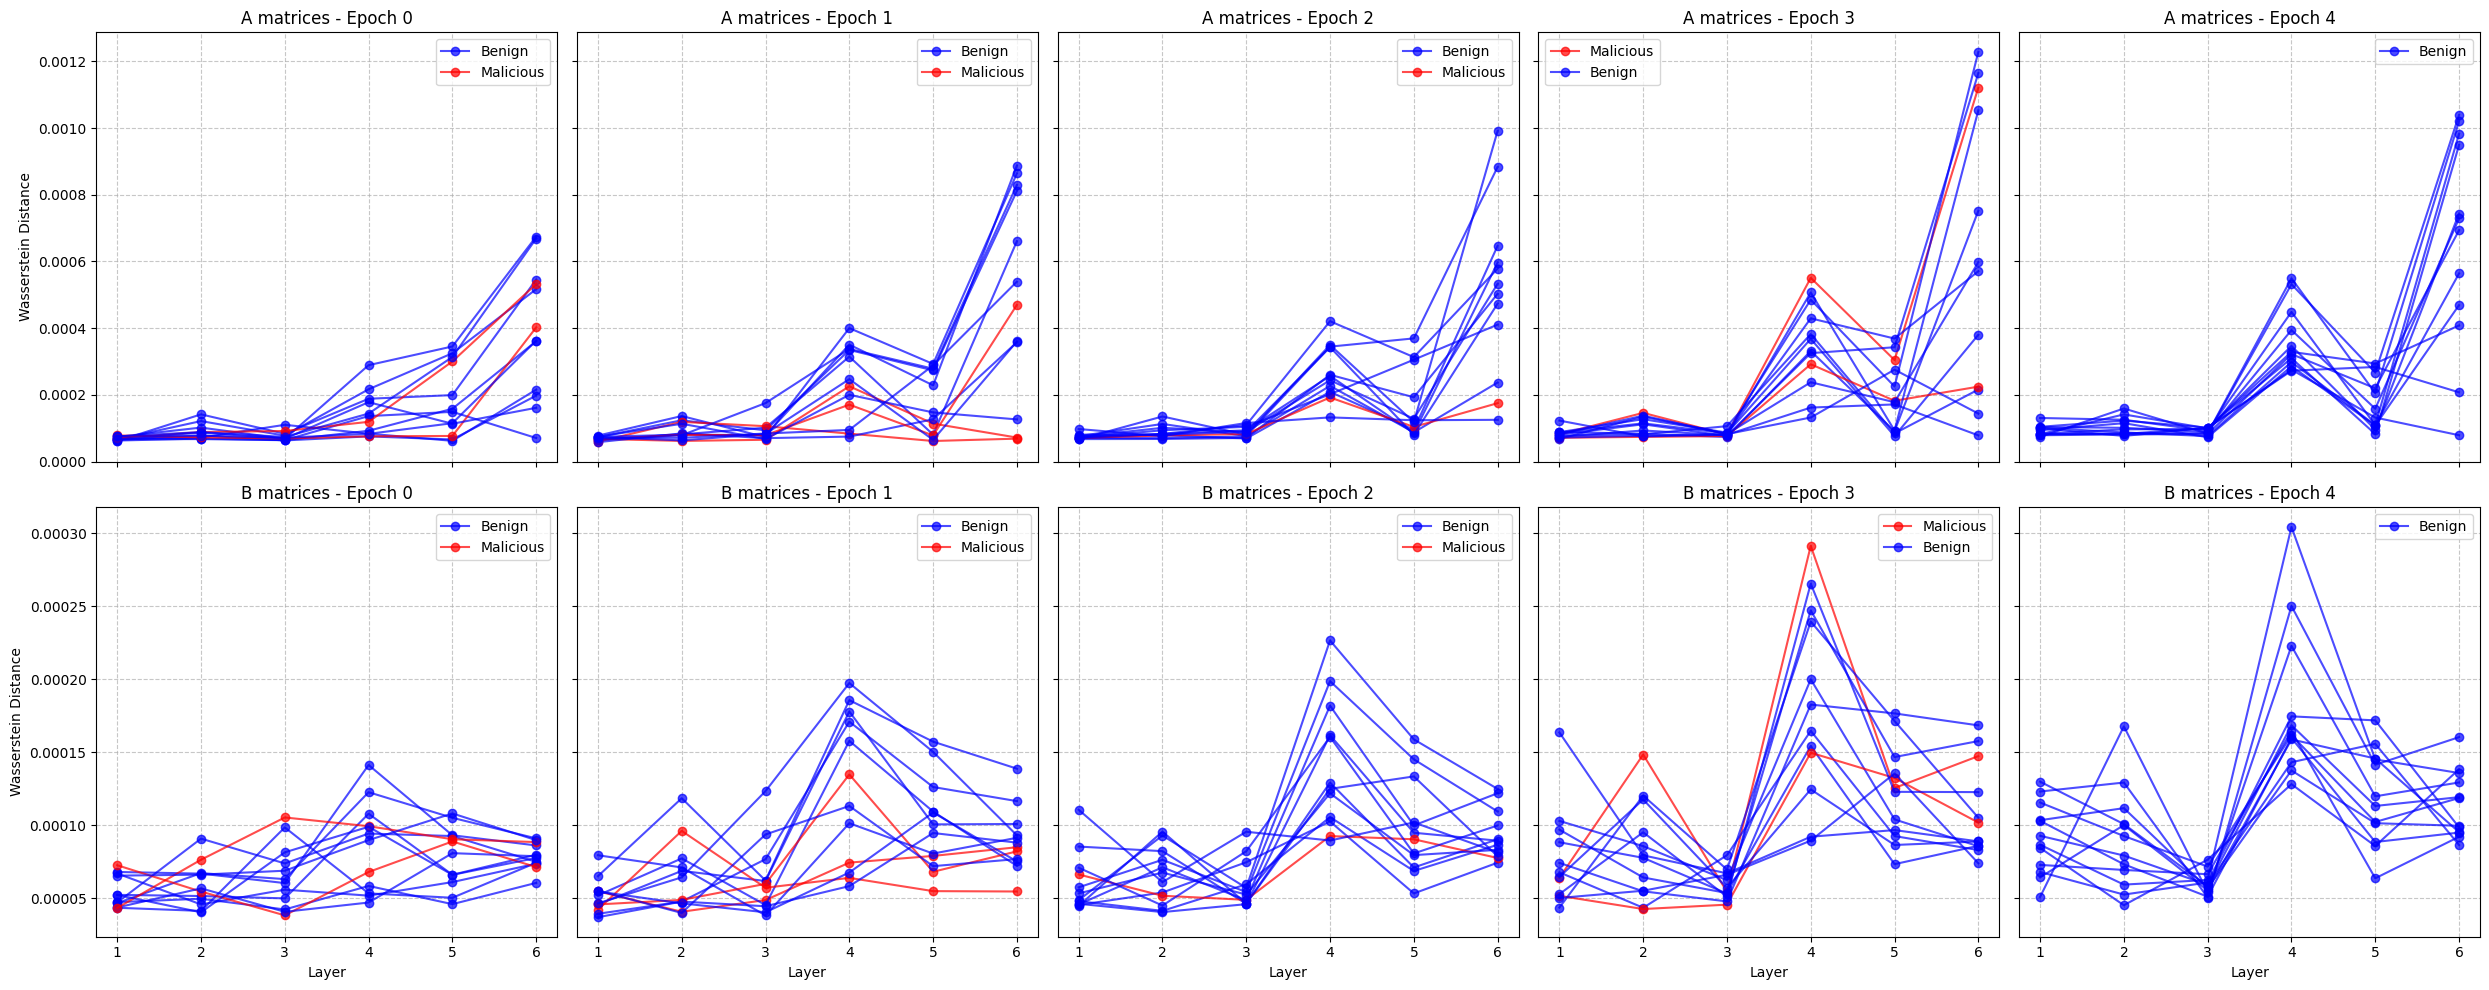

In [136]:
base_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
peft_model = PeftModel.from_pretrained(base_model, 'models/distilbert_sst2')
fig, A_distances, B_distances = plot_distances_across_epochs(model_name='distilbert', 
               clean_weights=peft_model.state_dict(), 
               epoch_data=client_weights)

In [114]:
client_weights['Epoch 0']['weights'][0]

{'base_model.model.pre_classifier.modules_to_save.default.weight': tensor([[-0.0396, -0.0332,  0.0006,  ...,  0.0095, -0.0131, -0.0105],
         [ 0.0097,  0.0152,  0.0063,  ...,  0.0042, -0.0326, -0.0373],
         [-0.0126, -0.0312,  0.0015,  ...,  0.0084,  0.0009,  0.0027],
         ...,
         [ 0.0157,  0.0392, -0.0187,  ...,  0.0185,  0.0175,  0.0098],
         [-0.0013, -0.0339, -0.0331,  ..., -0.0072,  0.0156,  0.0118],
         [ 0.0052, -0.0248, -0.0254,  ...,  0.0004, -0.0294,  0.0070]],
        device='mps:0'),
 'base_model.model.pre_classifier.modules_to_save.default.bias': tensor([-3.7637e-04, -4.6653e-03,  3.0019e-03, -1.0241e-04, -1.2319e-03,
         -1.2912e-03, -3.2585e-03, -1.2625e-03, -1.8576e-03,  2.1972e-03,
          1.9613e-03,  5.1701e-03,  3.1889e-03,  8.1683e-04, -2.7201e-03,
         -3.2075e-03, -1.5070e-03, -3.6848e-04, -1.0619e-03,  4.2518e-04,
          1.7023e-03, -2.8803e-03,  2.7881e-03, -2.9716e-03, -8.8724e-04,
         -2.8830e-03,  1.8166e-03,

In [76]:
clean_A_mat, clean_B_mat = extract_lora_qs(model_name='distilbert', 
                                              clients_state_dicts=[peft_model.state_dict()], 
                                              num_layers=6)

In [78]:
client_A_mat, client_B_mat = extract_lora_qs(model_name='distilbert', 
                                              clients_state_dicts=client_weights, 
                                              num_layers=6)


In [130]:
base_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
peft_model = PeftModel.from_pretrained(base_model, 
                                       'models/distilbert_sst2',
                                )
peft_model.train()
for name, param in peft_model.named_parameters():
    if 'lora' in name:
        print(name)
        print(param)
        print(param.requires_grad)
        break

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight
Parameter containing:
tensor([[-2.1051e-02, -3.2713e-02, -2.7385e-02,  ...,  7.8511e-03,
          6.9176e-03, -2.4440e-02],
        [-4.0401e-02,  2.5168e-02,  1.3265e-02,  ..., -3.6584e-02,
          2.3969e-02, -6.4650e-03],
        [-3.6634e-02,  4.0108e-02, -2.9997e-02,  ...,  3.5471e-02,
         -1.7535e-02, -2.8247e-02],
        ...,
        [ 1.9071e-02,  2.6737e-03,  3.7980e-02,  ..., -3.2323e-03,
         -1.0443e-03,  4.3930e-02],
        [-3.3932e-02, -2.9431e-02, -4.1074e-05,  ..., -2.5808e-02,
         -2.6085e-02,  3.2637e-02],
        [ 1.1905e-02, -2.5167e-02,  2.1587e-02,  ..., -2.6198e-02,
          1.6304e-02,  2.7079e-02]])
False


In [119]:
peft_model

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSdpaAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=76

In [105]:
client_weights['Epoch 2']['weights'][2]

{'base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight': tensor([[-2.1051e-02, -3.2713e-02, -2.7385e-02,  ...,  7.8511e-03,
           6.9176e-03, -2.4440e-02],
         [-4.0401e-02,  2.5168e-02,  1.3265e-02,  ..., -3.6584e-02,
           2.3969e-02, -6.4650e-03],
         [-3.6634e-02,  4.0108e-02, -2.9997e-02,  ...,  3.5471e-02,
          -1.7535e-02, -2.8247e-02],
         ...,
         [ 1.9071e-02,  2.6737e-03,  3.7980e-02,  ..., -3.2323e-03,
          -1.0443e-03,  4.3930e-02],
         [-3.3932e-02, -2.9431e-02, -4.1074e-05,  ..., -2.5808e-02,
          -2.6085e-02,  3.2637e-02],
         [ 1.1905e-02, -2.5167e-02,  2.1587e-02,  ..., -2.6198e-02,
           1.6304e-02,  2.7079e-02]], device='mps:0'),
 'base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight': tensor([[-0.0035, -0.0111,  0.0085,  ...,  0.0109, -0.0119, -0.0118],
         [-0.0023,  0.0126, -0.0057,  ..., -0.0076, -0.0045,  0.0112],
         [ 0.0032,